<a href="https://www.kaggle.com/code/maryammoghaddasbayat/yogaposereconitionediited18june?scriptVersionId=332040826" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

RAW_BASE = "/kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET"

PROJECT_DIR = "/kaggle/working/Yoga-Pose-Recognition"
FIGURE_DIR = os.path.join(PROJECT_DIR, "Figures")
MODEL_DIR = os.path.join(PROJECT_DIR, "Models")
RESULT_DIR = os.path.join(PROJECT_DIR, "Results")
CLEAN_BASE = os.path.join(PROJECT_DIR, "Clean_Dataset")

for folder in [PROJECT_DIR, FIGURE_DIR, MODEL_DIR, RESULT_DIR, CLEAN_BASE]:
    os.makedirs(folder, exist_ok=True)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
NUM_CLASSES = 5

class_names = ["downdog", "goddess", "plank", "tree", "warrior2"]

display_names = {
    "downdog": "Downward Dog",
    "goddess": "Goddess",
    "plank": "Plank",
    "tree": "Tree",
    "warrior2": "Warrior II"
}

print("Setup completed successfully.")
print("TensorFlow version:", tf.__version__)
print("Dataset path:", RAW_BASE)

2026-07-02 07:48:16.449376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782978496.649801      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782978496.709189      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782978497.194077      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782978497.194126      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782978497.194130      16 computation_placer.cc:177] computation placer alr

Setup completed successfully.
TensorFlow version: 2.19.0
Dataset path: /kaggle/input/datasets/niharika41298/yoga-poses-dataset/DATASET


In [2]:
# ============================================================
# Cell 3: Clean Dataset
# ============================================================

clean_count = 0
bad_files = []

for split in ["TRAIN", "TEST"]:
    split_path = os.path.join(RAW_BASE, split)

    for cls in class_names:
        in_dir = os.path.join(split_path, cls)
        out_dir = os.path.join(CLEAN_BASE, split, cls)

        os.makedirs(out_dir, exist_ok=True)

        for file in os.listdir(in_dir):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                in_path = os.path.join(in_dir, file)
                out_path = os.path.join(out_dir, os.path.splitext(file)[0] + ".jpg")

                try:
                    img = Image.open(in_path).convert("RGB")
                    img = img.resize(IMG_SIZE)
                    img.save(out_path, "JPEG", quality=95)
                    clean_count += 1

                except Exception as error:
                    bad_files.append({
                        "split": split,
                        "class": cls,
                        "file": file,
                        "error": str(error)
                    })

bad_files_df = pd.DataFrame(bad_files)

bad_files_df.to_csv(
    os.path.join(RESULT_DIR, "bad_files_report.csv"),
    index=False
)

print("Clean images saved:", clean_count)
print("Bad files skipped:", len(bad_files))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Clean images saved: 1550
Bad files skipped: 0


In [3]:
# ============================================================
# Cell 4: Dataset Statistics
# ============================================================

records = []

for split in ["TRAIN", "TEST"]:
    for cls in class_names:
        folder = os.path.join(CLEAN_BASE, split, cls)
        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(".jpg")
        ])

        records.append({
            "Split": split,
            "Class": display_names[cls],
            "Number of Images": count
        })

dataset_stats = pd.DataFrame(records)

dataset_stats.to_excel(
    os.path.join(RESULT_DIR, "dataset_statistics.xlsx"),
    index=False
)

display(dataset_stats)

print("Dataset statistics saved.")

,Split,Class,Number of Images
0,TRAIN,Downward Dog,222
1,TRAIN,Goddess,180
2,TRAIN,Plank,266
3,TRAIN,Tree,160
4,TRAIN,Warrior II,252
5,TEST,Downward Dog,97
6,TEST,Goddess,80
7,TEST,Plank,115
8,TEST,Tree,69
9,TEST,Warrior II,109


Dataset statistics saved.


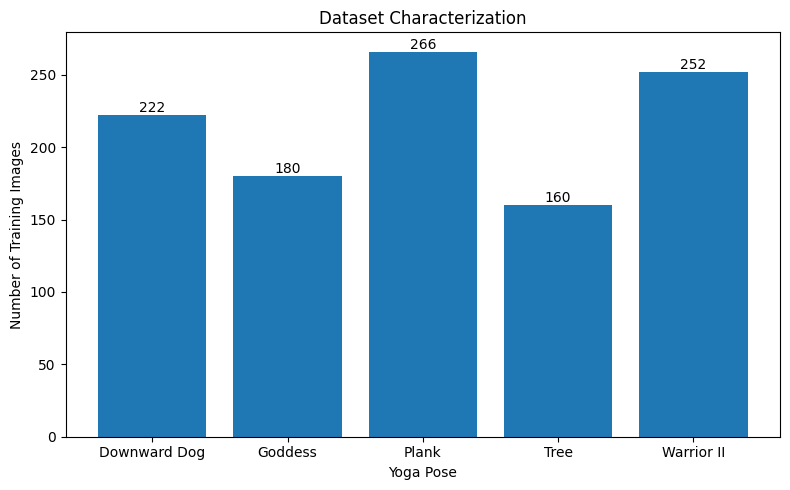

Dataset characterization figure saved.


In [4]:
# ============================================================
# Cell 5: Dataset Characterization Figure
# ============================================================

train_stats = dataset_stats[dataset_stats["Split"] == "TRAIN"]

plt.figure(figsize=(8,5))

bars = plt.bar(
    train_stats["Class"],
    train_stats["Number of Images"]
)

plt.title("Dataset Characterization")
plt.xlabel("Yoga Pose")
plt.ylabel("Number of Training Images")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "dataset_characterization_dashboard.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Dataset characterization figure saved.")

In [5]:
# ============================================================
# Restore Output Directories
# ============================================================

import os

PROJECT_DIR = "/kaggle/working/Yoga-Pose-Recognition"

FIGURE_DIR = os.path.join(PROJECT_DIR, "Figures")
RESULT_DIR = os.path.join(PROJECT_DIR, "Results")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Directories restored.")
print(FIGURE_DIR)
print(RESULT_DIR)

Directories restored.
/kaggle/working/Yoga-Pose-Recognition/Figures
/kaggle/working/Yoga-Pose-Recognition/Results


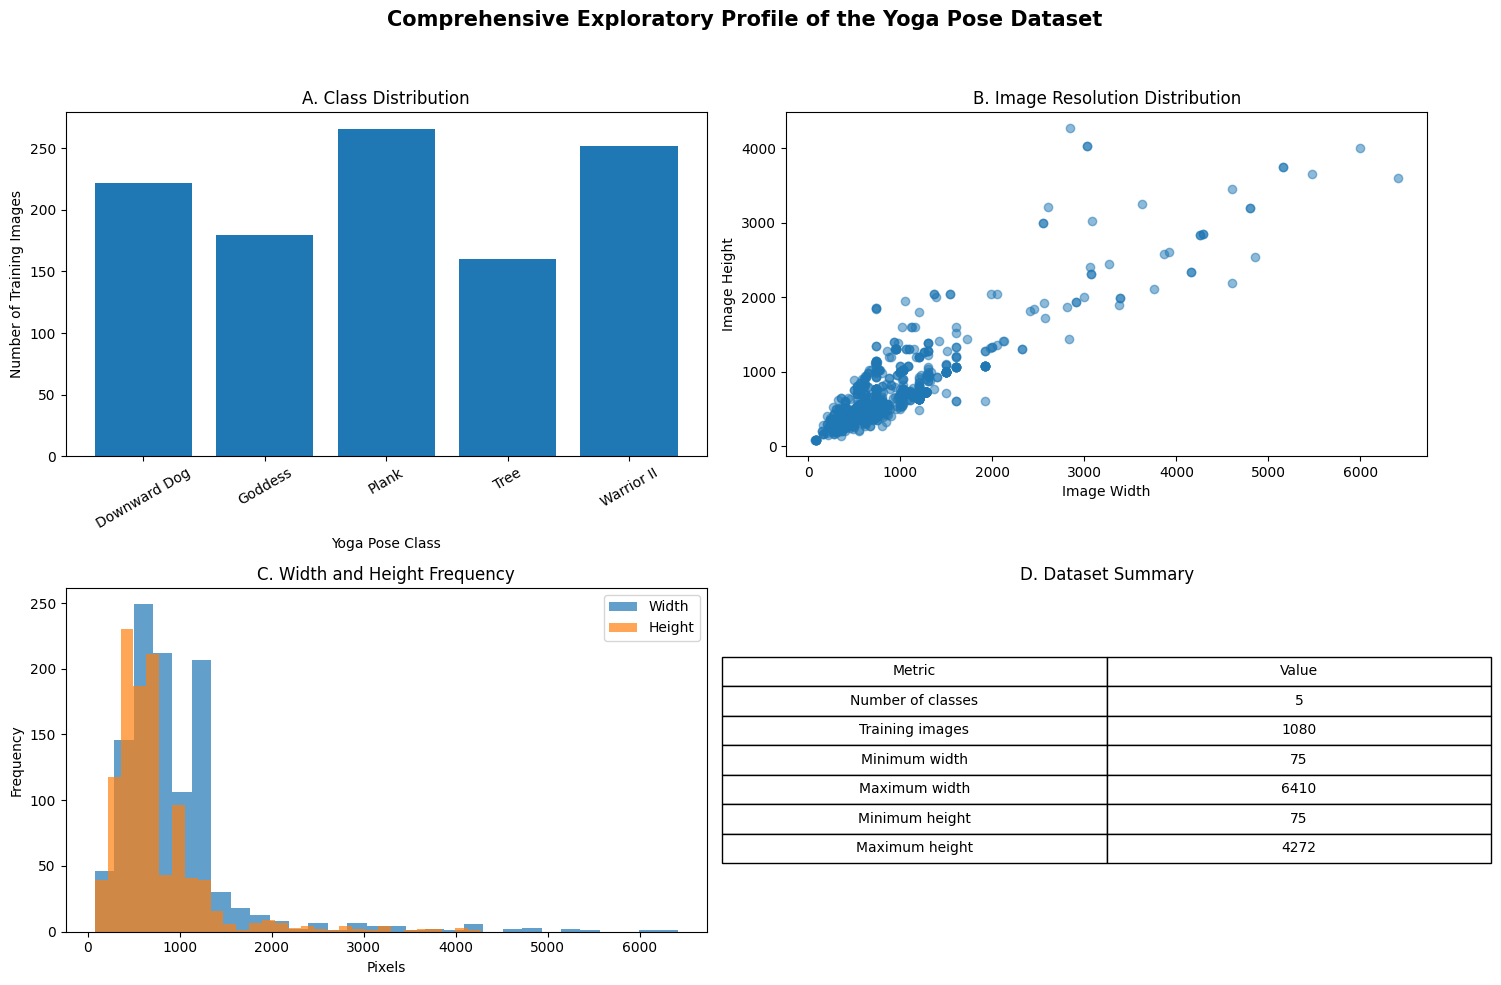

,Metric,Value
0,Number of classes,5
1,Training images,1080
2,Minimum width,75
3,Maximum width,6410
4,Minimum height,75
5,Maximum height,4272


Comprehensive exploratory profile saved.


In [6]:
# ============================================================
# Cell 5: Comprehensive Exploratory Profile of the Dataset
# ============================================================

eda_records = []

for cls in class_names:
    folder = os.path.join(RAW_BASE, "TRAIN", cls)

    for file in os.listdir(folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(folder, file)

            try:
                img = Image.open(image_path)
                width, height = img.size

                eda_records.append({
                    "class": cls,
                    "image_path": image_path,
                    "width": width,
                    "height": height
                })

            except Exception as error:
                pass

df = pd.DataFrame(eda_records)

df["display_class"] = df["class"].map(display_names)

class_counts = df["display_class"].value_counts().reindex([
    "Downward Dog",
    "Goddess",
    "Plank",
    "Tree",
    "Warrior II"
])

summary = pd.DataFrame({
    "Metric": [
        "Number of classes",
        "Training images",
        "Minimum width",
        "Maximum width",
        "Minimum height",
        "Maximum height"
    ],
    "Value": [
        df["display_class"].nunique(),
        len(df),
        df["width"].min(),
        df["width"].max(),
        df["height"].min(),
        df["height"].max()
    ]
})

class_counts.to_csv(
    os.path.join(RESULT_DIR, "train_class_distribution.csv")
)

summary.to_excel(
    os.path.join(RESULT_DIR, "dataset_summary.xlsx"),
    index=False
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle(
    "Comprehensive Exploratory Profile of the Yoga Pose Dataset",
    fontsize=15,
    fontweight="bold"
)

axes[0, 0].bar(
    class_counts.index,
    class_counts.values
)

axes[0, 0].set_title("A. Class Distribution")
axes[0, 0].set_xlabel("Yoga Pose Class")
axes[0, 0].set_ylabel("Number of Training Images")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].scatter(
    df["width"],
    df["height"],
    alpha=0.5
)

axes[0, 1].set_title("B. Image Resolution Distribution")
axes[0, 1].set_xlabel("Image Width")
axes[0, 1].set_ylabel("Image Height")

axes[1, 0].hist(
    df["width"],
    bins=30,
    alpha=0.7,
    label="Width"
)

axes[1, 0].hist(
    df["height"],
    bins=30,
    alpha=0.7,
    label="Height"
)

axes[1, 0].set_title("C. Width and Height Frequency")
axes[1, 0].set_xlabel("Pixels")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

axes[1, 1].axis("off")
axes[1, 1].set_title("D. Dataset Summary")

table = axes[1, 1].table(
    cellText=summary.values,
    colLabels=summary.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "comprehensive_exploratory_profile.pdf"
    ),
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

display(summary)

print("Comprehensive exploratory profile saved.")

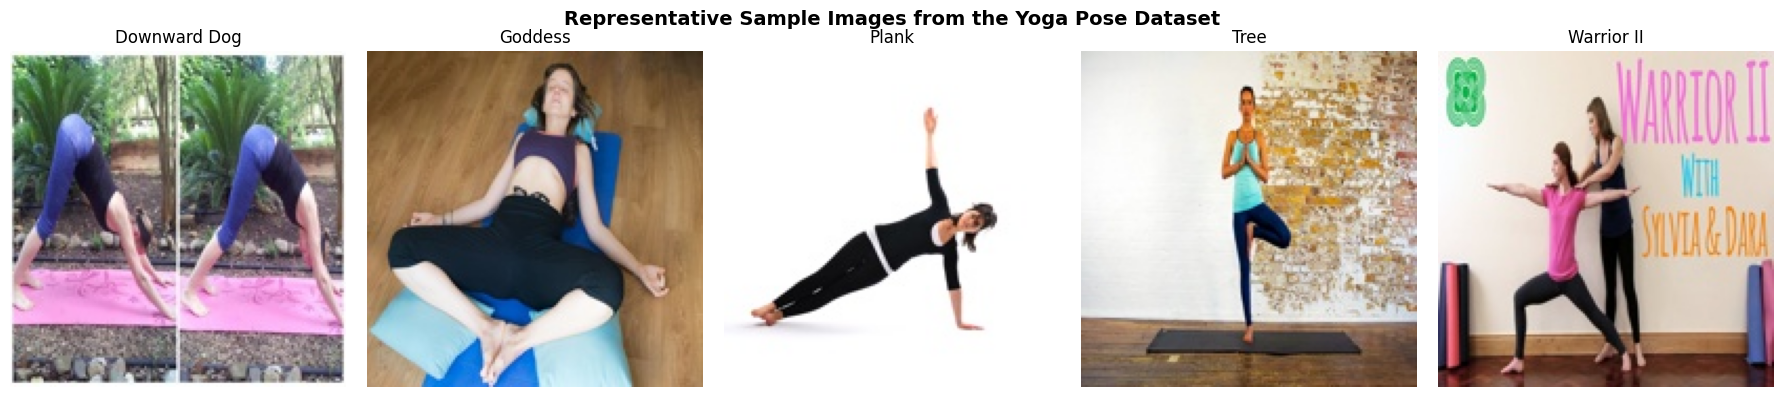

Representative sample images figure saved.


In [7]:
# ============================================================
# Cell 6: Representative Sample Images
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cls in enumerate(class_names):
    folder = os.path.join(CLEAN_BASE, "TRAIN", cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(".jpg")]

    sample_file = random.choice(files)
    image_path = os.path.join(folder, sample_file)

    img = Image.open(image_path).convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(display_names[cls])
    axes[i].axis("off")

plt.suptitle("Representative Sample Images from the Yoga Pose Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "representative_sample_images.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Representative sample images figure saved.")

In [8]:
# ============================================================
# Cell 7: TensorFlow Data Pipeline
# ============================================================

train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLEAN_BASE, "TRAIN"),
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLEAN_BASE, "TRAIN"),
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLEAN_BASE, "TEST"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

print("Training batches:", len(train_data))
print("Validation batches:", len(val_data))
print("Test batches:", len(test_data))
print("Data pipeline completed successfully.")

Found 1080 files belonging to 5 classes.
Using 864 files for training.
Found 1080 files belonging to 5 classes.
Using 216 files for validation.
Found 470 files belonging to 5 classes.
Training batches: 27
Validation batches: 7
Test batches: 15
Data pipeline completed successfully.


2026-07-02 07:49:33.428490: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


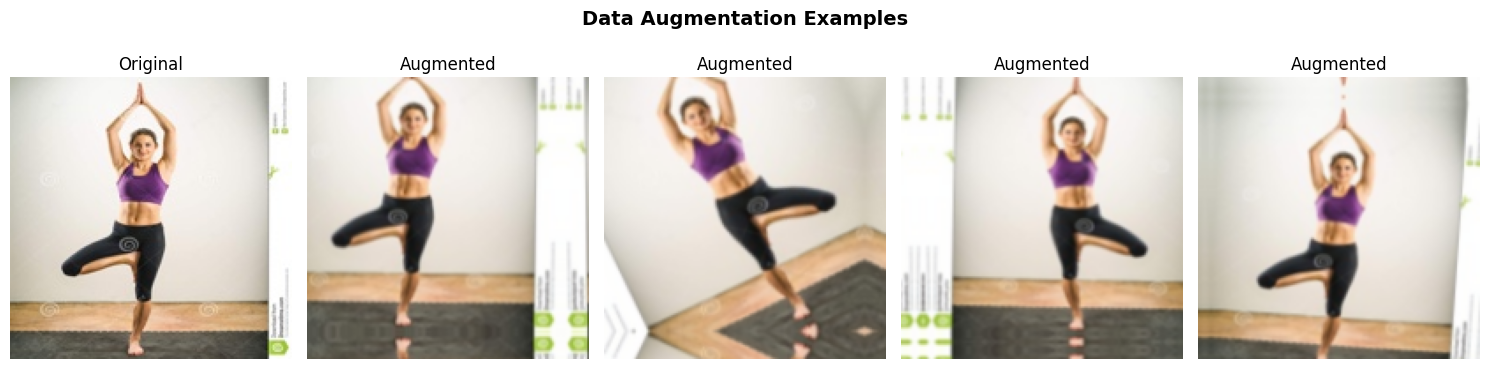

Data augmentation figure saved.


In [9]:
# ============================================================
# Cell 8: Data Augmentation Examples
# ============================================================

augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

sample_folder = os.path.join(CLEAN_BASE, "TRAIN", "tree")
sample_file = random.choice([
    f for f in os.listdir(sample_folder)
    if f.lower().endswith(".jpg")
])

sample_path = os.path.join(sample_folder, sample_file)

img = Image.open(sample_path).convert("RGB")
img_array = np.array(img)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented_img = augmentation(
        tf.expand_dims(img_array, 0),
        training=True
    )

    axes[i].imshow(augmented_img[0].numpy().astype("uint8"))
    axes[i].set_title("Augmented")
    axes[i].axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "data_augmentation_examples.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Data augmentation figure saved.")

In [10]:
# ============================================================
# Cell 9: Custom CNN Model and Training
# ============================================================

custom_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

callbacks_cnn = [
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "custom_cnn_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(
        os.path.join(RESULT_DIR, "custom_cnn_training_log.csv"),
        append=False
    )
]

history_cnn = custom_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=callbacks_cnn
)

custom_cnn.save(
    os.path.join(MODEL_DIR, "custom_cnn_final.keras")
)

print("Custom CNN training completed and saved.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step - accuracy: 0.2028 - loss: 1.8414
Epoch 1: val_accuracy improved from None to 0.31944, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2361 - loss: 1.6875 - val_accuracy: 0.3194 - val_loss: 1.5733
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.3479 - loss: 1.5051
Epoch 2: val_accuracy improved from 0.31944 to 0.51389, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/custom_cnn_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3993 - loss: 1.4473 - val_accuracy: 0.5139 - val_loss: 1.4019
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.5640 - loss: 1.2147
Epoch 3: val_accuracy improved from 

In [11]:
# ============================================================
# Cell 10: MobileNetV2 Transfer Learning
# ============================================================

base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

callbacks_mobilenet = [
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "mobilenetv2_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(
        os.path.join(RESULT_DIR, "mobilenetv2_training_log.csv"),
        append=False
    )
]

history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks_mobilenet
)

mobilenet_model.save(
    os.path.join(MODEL_DIR, "mobilenetv2_final.keras")
)

print("MobileNetV2 training completed and saved.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.2089 - loss: 2.2478
Epoch 1: val_accuracy improved from None to 0.34722, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras

Epoch 1: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 512ms/step - accuracy: 0.2153 - loss: 2.0572 - val_accuracy: 0.3472 - val_loss: 1.5443
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2863 - loss: 1.6760
Epoch 2: val_accuracy improved from 0.34722 to 0.48148, saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras

Epoch 2: finished saving model to /kaggle/working/Yoga-Pose-Recognition/Models/mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 455ms/step - accuracy: 0.3171 - loss: 1.6277 - val_accuracy: 0.4815 - val_loss: 1.3204
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.4011 - loss: 1.4246
Epoch 3: val_accuracy i

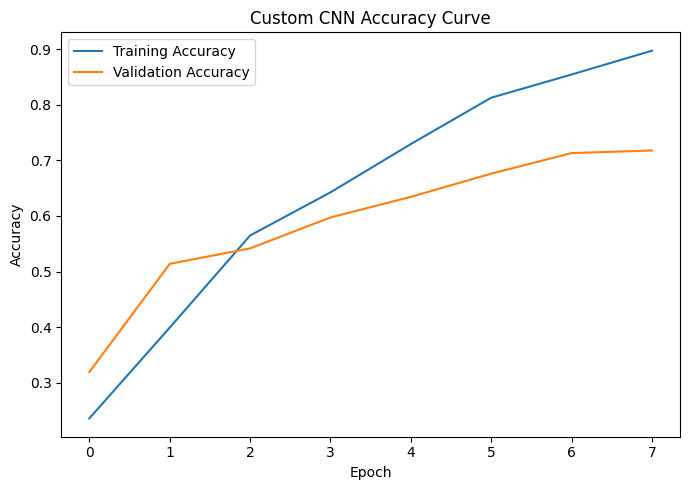

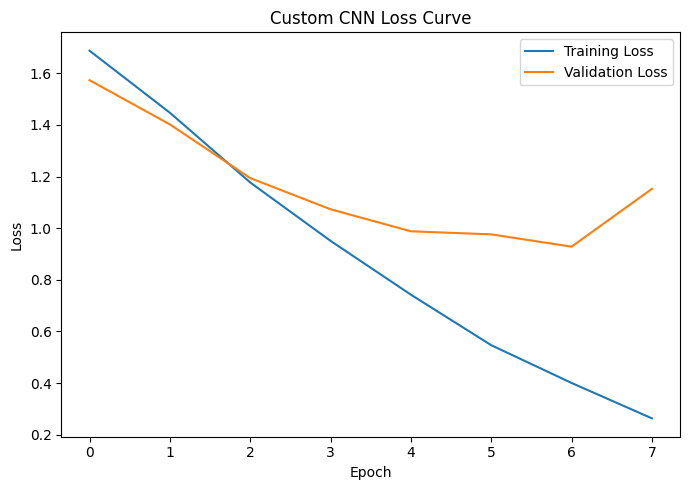

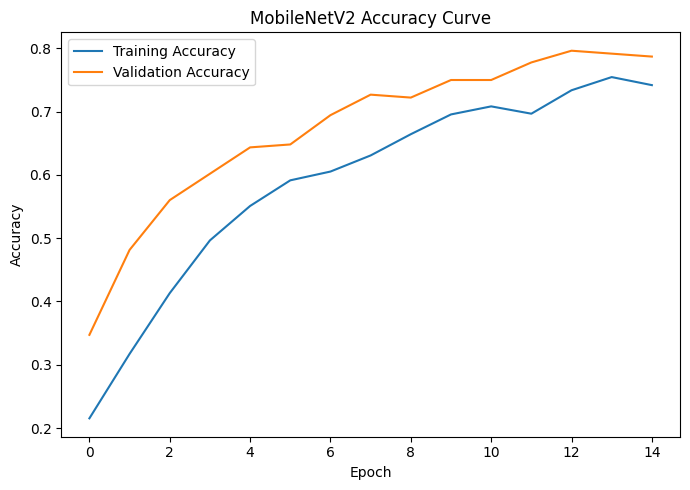

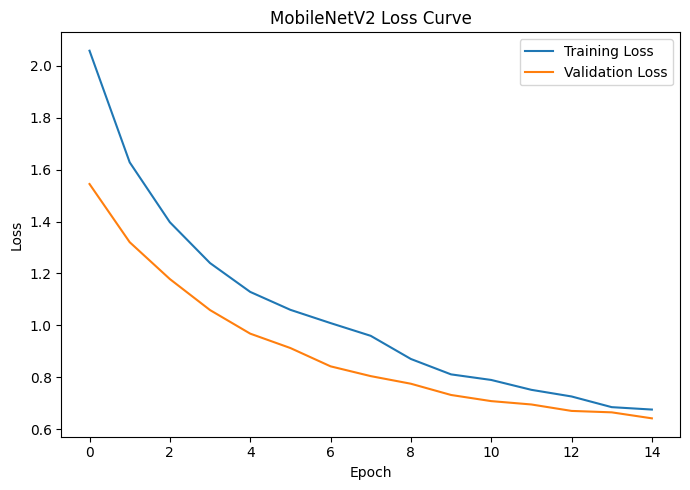

Training curves saved and displayed.


In [12]:
# ============================================================
# Cell 11: Training Curves
# ============================================================

custom_history_df = pd.DataFrame(history_cnn.history)
mobilenet_history_df = pd.DataFrame(history_mobilenet.history)

custom_history_df.to_excel(
    os.path.join(RESULT_DIR, "custom_cnn_history.xlsx"),
    index=False
)

mobilenet_history_df.to_excel(
    os.path.join(RESULT_DIR, "mobilenetv2_history.xlsx"),
    index=False
)

plt.figure(figsize=(7,5))
plt.plot(custom_history_df["accuracy"], label="Training Accuracy")
plt.plot(custom_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "custom_cnn_accuracy_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(custom_history_df["loss"], label="Training Loss")
plt.plot(custom_history_df["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "custom_cnn_loss_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(mobilenet_history_df["accuracy"], label="Training Accuracy")
plt.plot(mobilenet_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "mobilenetv2_accuracy_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(mobilenet_history_df["loss"], label="Training Loss")
plt.plot(mobilenet_history_df["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "mobilenetv2_loss_curve.pdf"), dpi=300, bbox_inches="tight")
plt.show()

print("Training curves saved and displayed.")

In [13]:
# ============================================================
# Cell 12: Final Evaluation
# ============================================================

y_true = np.concatenate([y for x, y in test_data], axis=0)

y_pred_prob = mobilenet_model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=[display_names[c] for c in class_names],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_excel(
    os.path.join(RESULT_DIR, "mobilenetv2_classification_report.xlsx")
)

print("Classification report saved.")

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 397ms/step


,precision,recall,f1-score,support
Downward Dog,0.977273,0.886598,0.929730,97.000000
Goddess,0.684932,0.625000,0.653595,80.000000
Plank,0.933333,0.852174,0.890909,115.000000
Tree,0.715909,0.913043,0.802548,69.000000
Warrior II,0.784483,0.834862,0.808889,109.000000
accuracy,0.825532,0.825532,0.825532,0.825532
macro avg,0.819186,0.822336,0.817134,470.000000
weighted avg,0.833680,0.825532,0.826533,470.000000


Classification report saved.


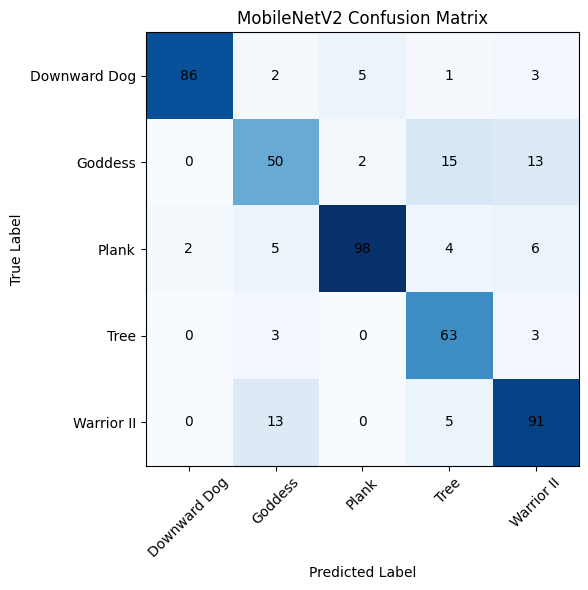

Confusion matrix saved.


In [14]:
# ============================================================
# Cell 13: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    [display_names[c] for c in class_names],
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    [display_names[c] for c in class_names]
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "mobilenetv2_confusion_matrix.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved.")

,Model,Test Accuracy,Test Loss
0,Custom CNN,80.638295,0.588134
1,MobileNetV2,82.553190,0.432323


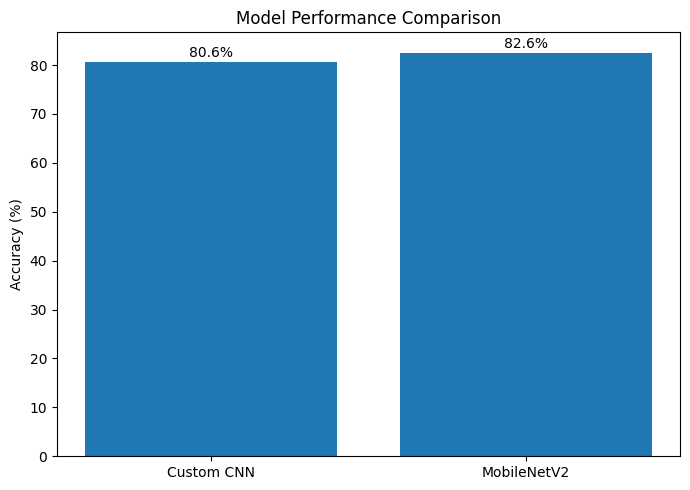

         Model  Test Accuracy  Test Loss
0   Custom CNN      80.638295   0.588134
1  MobileNetV2      82.553190   0.432323


In [15]:
# ============================================================
# Cell 14: Model Comparison
# ============================================================

custom_loss, custom_acc = custom_cnn.evaluate(
    test_data,
    verbose=0
)

mobile_loss, mobile_acc = mobilenet_model.evaluate(
    test_data,
    verbose=0
)

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [
        custom_acc * 100,
        mobile_acc * 100
    ],
    "Test Loss": [
        custom_loss,
        mobile_loss
    ]
})

display(comparison_df)

comparison_df.to_excel(
    os.path.join(
        RESULT_DIR,
        "model_comparison.xlsx"
    ),
    index=False
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "model_performance_comparison.pdf"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(comparison_df)

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 402ms/step


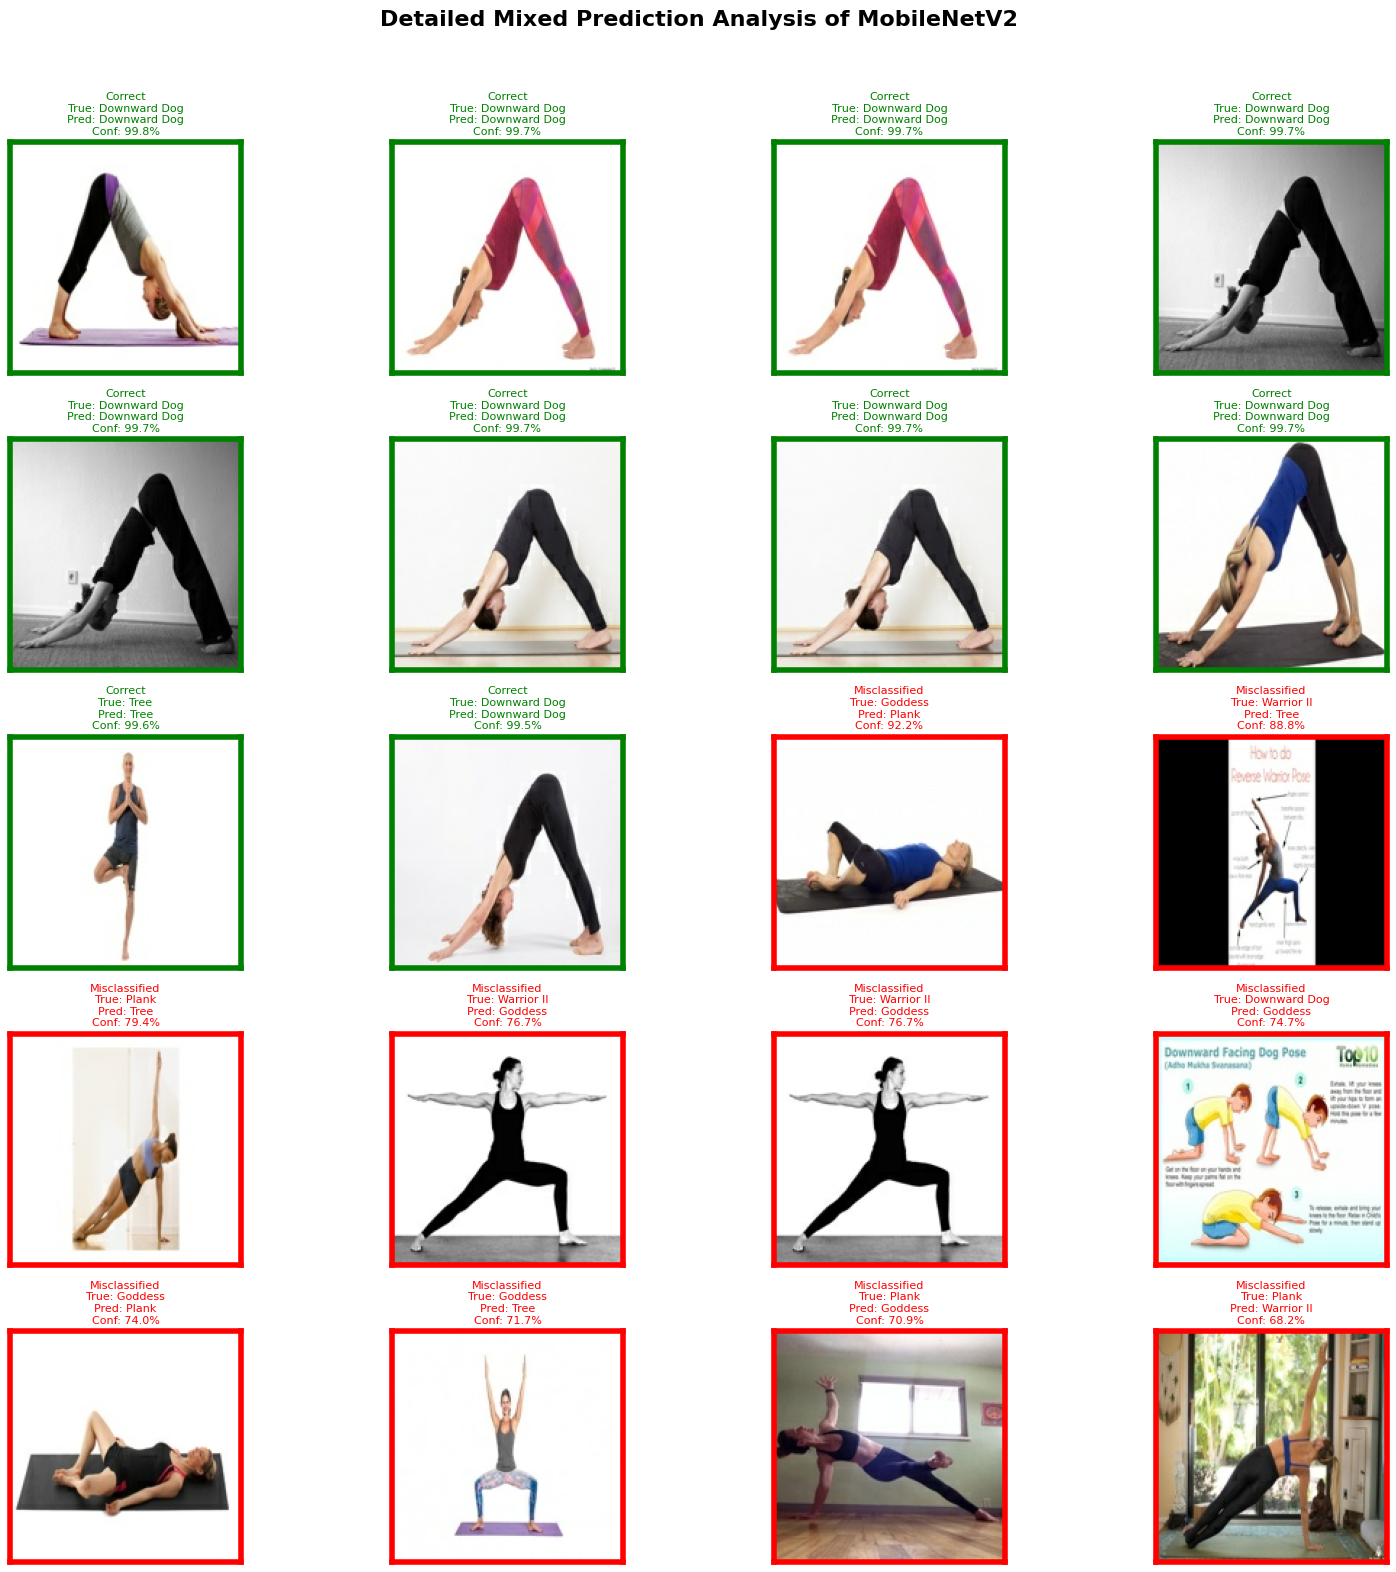

Detailed mixed prediction analysis figure saved.


In [16]:
# ============================================================
# Cell 15: Detailed Mixed Prediction Analysis
# ============================================================

all_images = []
all_labels = []

for x, y in test_data:
    all_images.append(x.numpy())
    all_labels.append(y.numpy())

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

pred_probs_all = mobilenet_model.predict(all_images)
pred_labels_all = np.argmax(pred_probs_all, axis=1)
confidence_all = np.max(pred_probs_all, axis=1)

correct_indices = np.where(pred_labels_all == all_labels)[0]
wrong_indices = np.where(pred_labels_all != all_labels)[0]

correct_sorted = sorted(
    correct_indices,
    key=lambda idx: confidence_all[idx],
    reverse=True
)

wrong_sorted = sorted(
    wrong_indices,
    key=lambda idx: confidence_all[idx],
    reverse=True
)

selected_indices = correct_sorted[:10] + wrong_sorted[:10]

plt.figure(figsize=(16,16))

for i, idx in enumerate(selected_indices):
    ax = plt.subplot(5,4,i+1)

    ax.imshow(all_images[idx].astype("uint8"))
    ax.set_xticks([])
    ax.set_yticks([])

    true_label = display_names[class_names[int(all_labels[idx])]]
    pred_label = display_names[class_names[int(pred_labels_all[idx])]]
    confidence = confidence_all[idx] * 100

    is_correct = int(all_labels[idx]) == int(pred_labels_all[idx])

    border_color = "green" if is_correct else "red"
    status = "Correct" if is_correct else "Misclassified"

    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    ax.set_title(
        f"{status}\nTrue: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
        color=border_color,
        fontsize=8
    )

plt.suptitle(
    "Detailed Mixed Prediction Analysis of MobileNetV2",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.savefig(
    os.path.join(FIGURE_DIR, "detailed_mixed_prediction_analysis.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Detailed mixed prediction analysis figure saved.")

,Class,F1 Score
0,Downward Dog,0.929730
1,Goddess,0.653595
2,Plank,0.890909
3,Tree,0.802548
4,Warrior II,0.808889


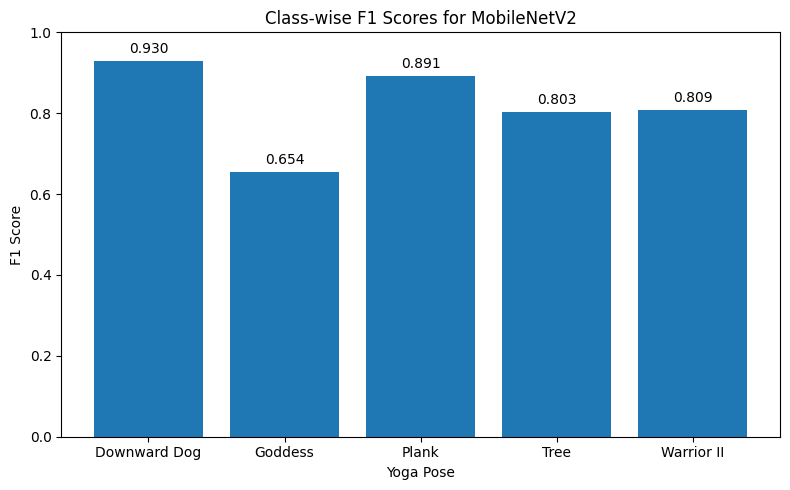

Class-wise F1 score figure saved.


In [17]:
# ============================================================
# Cell 16: Class-wise F1 Scores
# ============================================================

f1_df = report_df.loc[
    [display_names[c] for c in class_names],
    ["f1-score"]
].reset_index()

f1_df.columns = ["Class", "F1 Score"]

display(f1_df)

f1_df.to_excel(
    os.path.join(RESULT_DIR, "classwise_f1_scores.xlsx"),
    index=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    f1_df["Class"],
    f1_df["F1 Score"]
)

plt.title("Class-wise F1 Scores for MobileNetV2")
plt.xlabel("Yoga Pose")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "classwise_f1_scores.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Class-wise F1 score figure saved.")

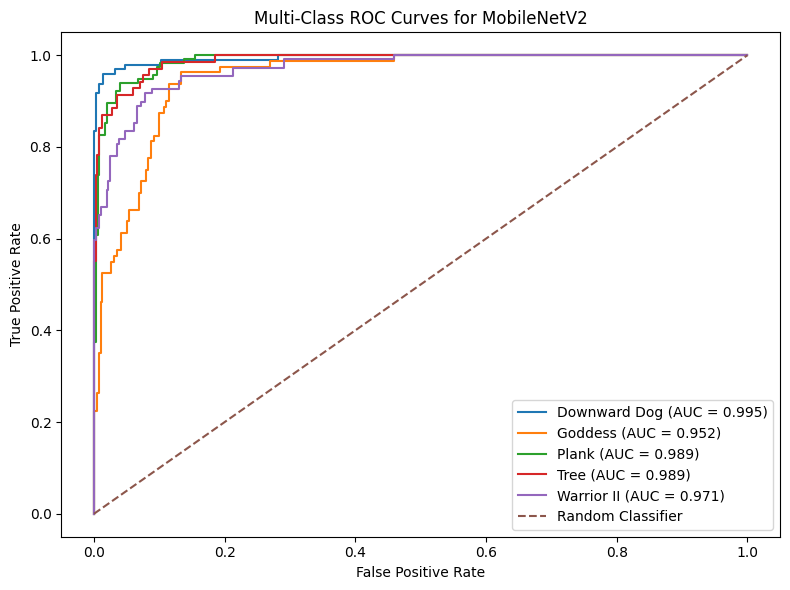

,Class,ROC-AUC
0,Downward Dog,0.994555
1,Goddess,0.951795
2,Plank,0.988536
3,Tree,0.988724
4,Warrior II,0.971257


Multi-class ROC curve figure and ROC-AUC table saved.


In [18]:
# ============================================================
# Multi-Class ROC Curves for MobileNetV2
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(
    y_true,
    classes=list(range(NUM_CLASSES))
)

roc_results = []

plt.figure(figsize=(8, 6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    roc_results.append({
        "Class": display_names[cls],
        "ROC-AUC": roc_auc
    })

    plt.plot(
        fpr,
        tpr,
        label=f"{display_names[cls]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("Multi-Class ROC Curves for MobileNetV2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "mobilenetv2_multiclass_roc_curves.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

roc_df = pd.DataFrame(roc_results)
display(roc_df)

roc_df.to_excel(
    os.path.join(RESULT_DIR, "mobilenetv2_roc_auc_scores.xlsx"),
    index=False
)

print("Multi-class ROC curve figure and ROC-AUC table saved.")

## Explainable AI Correction: Grad-CAM and SHAP

The following new cells add the Explainable AI part required by the professor. They create a new folder named `XAI_Figures` and save the Grad-CAM and SHAP outputs as PDF files. Run these cells after the MobileNetV2 evaluation and ROC-AUC cells, because they reuse `mobilenet_model`, `test_data`, `class_names`, `display_names`, `all_images`, `all_labels`, and `pred_probs_all`.

In [19]:

# ============================================================
# Cell 18A: Explainable AI Setup - New PDF Figure Folder
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

XAI_DIR = os.path.join(PROJECT_DIR, "XAI_Figures")
XAI_RESULT_DIR = os.path.join(PROJECT_DIR, "XAI_Results")
os.makedirs(XAI_DIR, exist_ok=True)
os.makedirs(XAI_RESULT_DIR, exist_ok=True)

# Make sure the full test arrays and prediction arrays exist.
# This allows the XAI cells to run even if the mixed-prediction cell was skipped.
try:
    all_images
    all_labels
    pred_probs_all
    pred_labels_all
    confidence_all
except NameError:
    all_images = []
    all_labels = []
    for x_batch, y_batch in test_data:
        all_images.append(x_batch.numpy())
        all_labels.append(y_batch.numpy())
    all_images = np.concatenate(all_images, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    pred_probs_all = mobilenet_model.predict(all_images, verbose=0)
    pred_labels_all = np.argmax(pred_probs_all, axis=1)
    confidence_all = np.max(pred_probs_all, axis=1)

# Choose representative images: three correct high-confidence examples and three high-confidence mistakes.
correct_indices = np.where(pred_labels_all == all_labels)[0]
wrong_indices = np.where(pred_labels_all != all_labels)[0]

correct_sorted = sorted(correct_indices, key=lambda idx: confidence_all[idx], reverse=True)
wrong_sorted = sorted(wrong_indices, key=lambda idx: confidence_all[idx], reverse=True)

selected_xai_indices = correct_sorted[:3] + wrong_sorted[:3]

selected_xai_df = pd.DataFrame({
    "image_index": selected_xai_indices,
    "true_class": [display_names[class_names[int(all_labels[i])]] for i in selected_xai_indices],
    "predicted_class": [display_names[class_names[int(pred_labels_all[i])]] for i in selected_xai_indices],
    "confidence": [float(confidence_all[i]) for i in selected_xai_indices],
    "case_type": ["Correct" if pred_labels_all[i] == all_labels[i] else "Misclassified" for i in selected_xai_indices]
})

selected_xai_df.to_excel(
    os.path.join(XAI_RESULT_DIR, "selected_xai_images.xlsx"),
    index=False
)

display(selected_xai_df)

print("XAI figure folder created:", XAI_DIR)
print("XAI result folder created:", XAI_RESULT_DIR)


,image_index,true_class,predicted_class,confidence,case_type
0,19,Downward Dog,Downward Dog,0.998395,Correct
1,61,Downward Dog,Downward Dog,0.997456,Correct
2,71,Downward Dog,Downward Dog,0.997456,Correct
3,162,Goddess,Plank,0.922478,Misclassified
4,426,Warrior II,Tree,0.888491,Misclassified
5,224,Plank,Tree,0.794378,Misclassified


XAI figure folder created: /kaggle/working/Yoga-Pose-Recognition/XAI_Figures
XAI result folder created: /kaggle/working/Yoga-Pose-Recognition/XAI_Results


MobileNetV2 base layer: mobilenetv2_1.00_160
Last convolutional layer used for Grad-CAM: Conv_1
Direct Grad-CAM model connection failed. Rebuilding a compatible Grad-CAM model.
Reason: The layer sequential_2 has never been called and thus has no defined output.


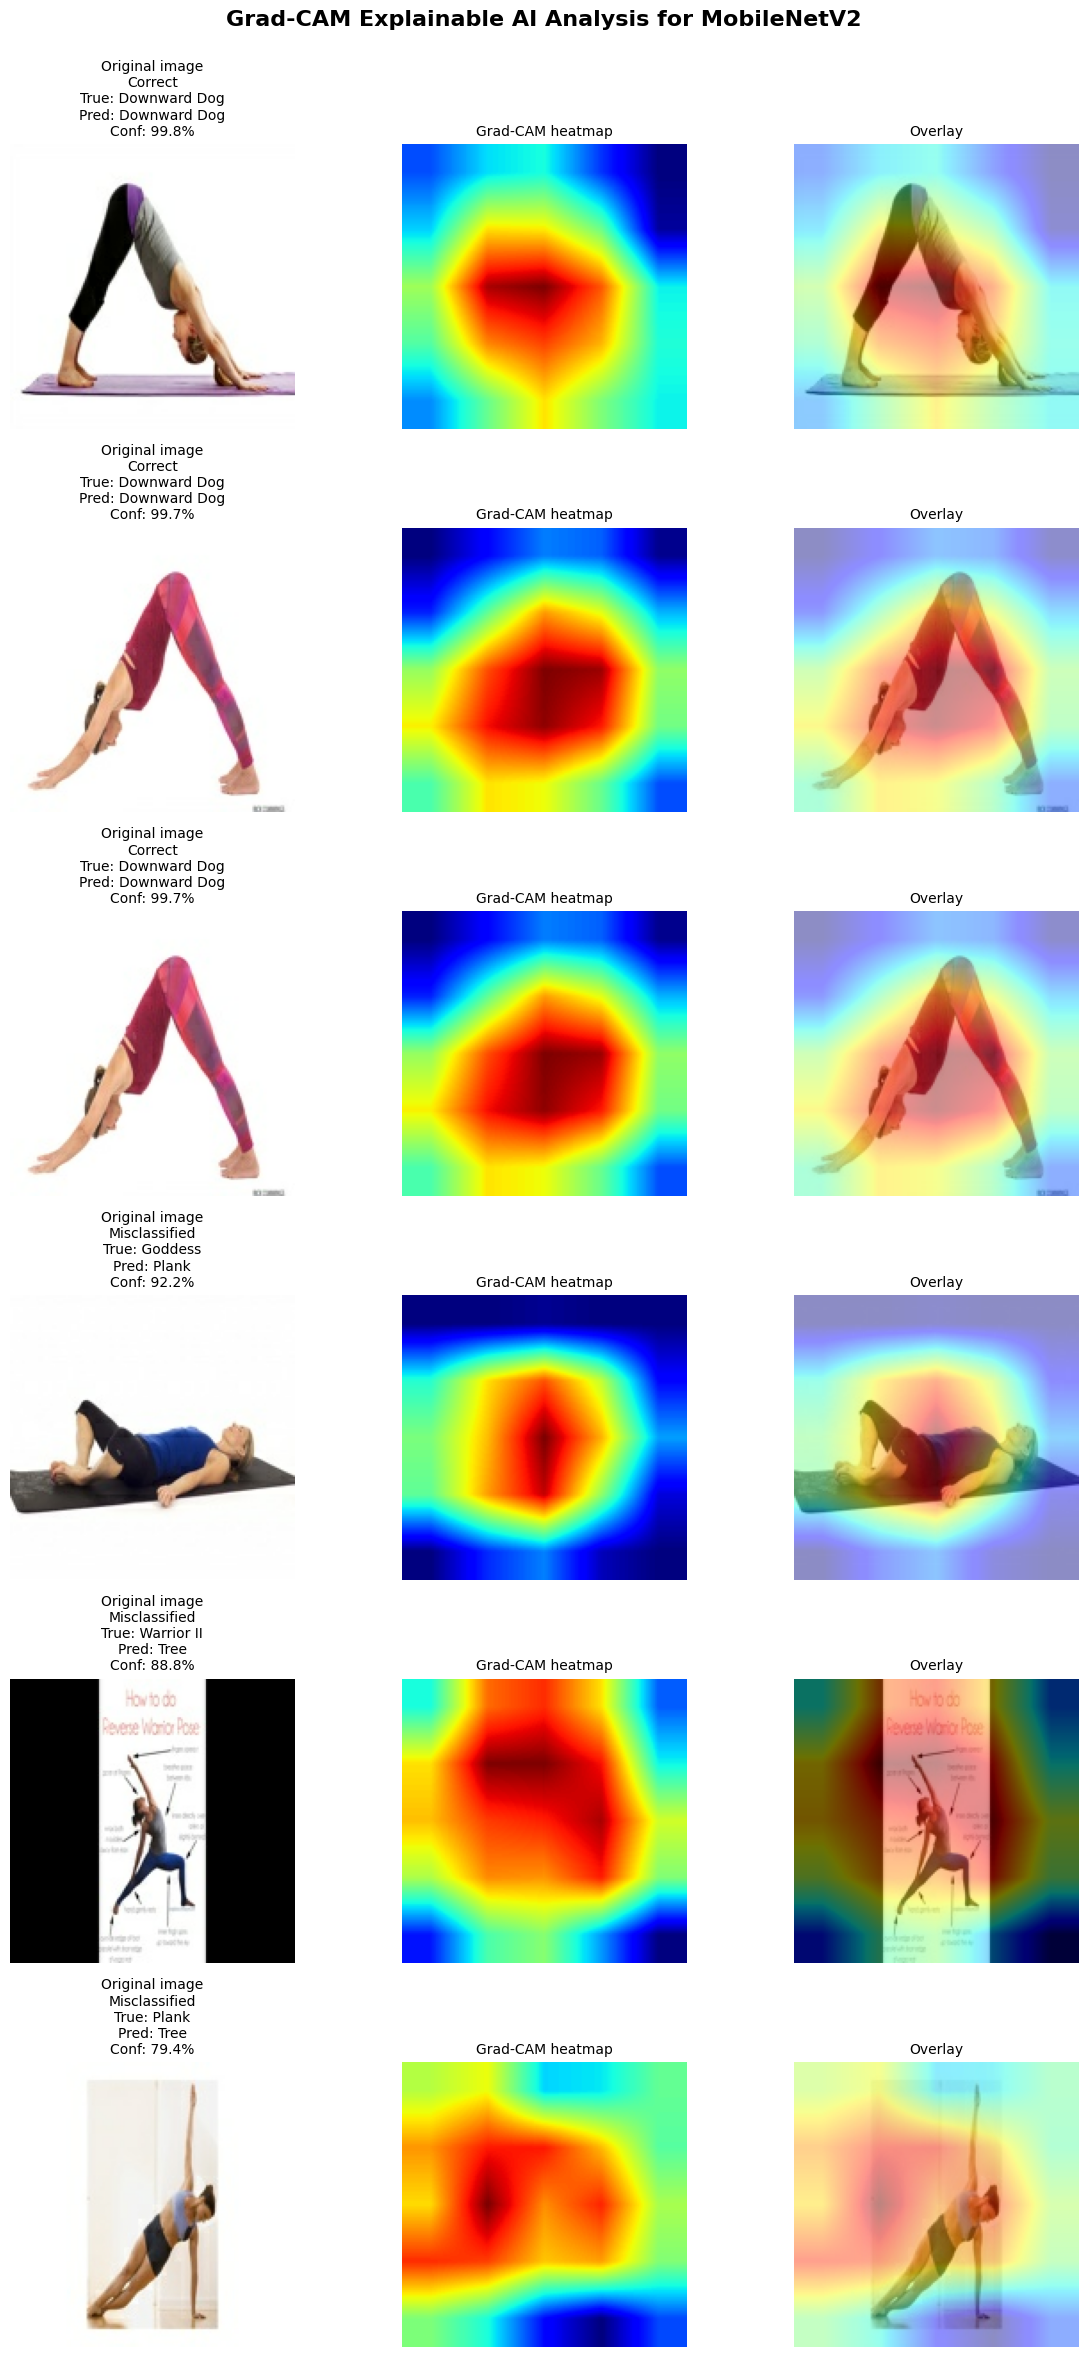

Grad-CAM PDF saved: /kaggle/working/Yoga-Pose-Recognition/XAI_Figures/gradcam_mobilenetv2_explainable_ai.pdf


In [20]:

# ============================================================
# Cell 18B: Grad-CAM for MobileNetV2 - Saved as PDF
# ============================================================

# Grad-CAM shows which image regions most influenced the model prediction.
# This code automatically finds the last convolutional layer inside the MobileNetV2 base.

def find_mobilenet_base(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenet" in layer.name.lower():
            return layer
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("Could not find the nested MobileNetV2 base model inside mobilenet_model.")

base_for_gradcam = find_mobilenet_base(mobilenet_model)

last_conv_layer_name = None
for layer in reversed(base_for_gradcam.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("MobileNetV2 base layer:", base_for_gradcam.name)
print("Last convolutional layer used for Grad-CAM:", last_conv_layer_name)

# Build Grad-CAM model. If the nested-layer graph causes an error, the fallback rebuilds the same architecture.
try:
    grad_model = tf.keras.models.Model(
        inputs=mobilenet_model.inputs,
        outputs=[
            base_for_gradcam.get_layer(last_conv_layer_name).output,
            mobilenet_model.output
        ]
    )
except Exception as e:
    print("Direct Grad-CAM model connection failed. Rebuilding a compatible Grad-CAM model.")
    print("Reason:", e)
    x_input = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    conv_extractor = tf.keras.Model(
        inputs=base_for_gradcam.input,
        outputs=[
            base_for_gradcam.get_layer(last_conv_layer_name).output,
            base_for_gradcam.output
        ]
    )
    conv_output, base_output = conv_extractor(x_input)
    x = mobilenet_model.layers[1](base_output)
    x = mobilenet_model.layers[2](x, training=False)
    x = mobilenet_model.layers[3](x)
    y_output = mobilenet_model.layers[4](x)
    grad_model = tf.keras.models.Model(inputs=x_input, outputs=[conv_output, y_output])


def make_gradcam_heatmap(img_array, model, predicted_class_index=None):
    img_tensor = tf.convert_to_tensor(img_array[None, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = model(img_tensor, training=False)
        if predicted_class_index is None:
            predicted_class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, predicted_class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def resize_heatmap_to_image(heatmap, image):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (image.shape[0], image.shape[1])
    ).numpy().squeeze()
    return heatmap_resized

# Create a multi-example Grad-CAM figure.
fig, axes = plt.subplots(len(selected_xai_indices), 3, figsize=(12, 4 * len(selected_xai_indices)))

if len(selected_xai_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(selected_xai_indices):
    img = all_images[idx].astype("float32")
    pred_class = int(pred_labels_all[idx])
    true_class = int(all_labels[idx])
    heatmap = make_gradcam_heatmap(img, grad_model, pred_class)
    heatmap_resized = resize_heatmap_to_image(heatmap, img)

    title_text = (
        f"{('Correct' if pred_class == true_class else 'Misclassified')}\n"
        f"True: {display_names[class_names[true_class]]}\n"
        f"Pred: {display_names[class_names[pred_class]]}\n"
        f"Conf: {confidence_all[idx] * 100:.1f}%"
    )

    axes[row, 0].imshow(np.clip(img.astype("uint8"), 0, 255))
    axes[row, 0].set_title("Original image\n" + title_text, fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap_resized, cmap="jet")
    axes[row, 1].set_title("Grad-CAM heatmap", fontsize=10)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(np.clip(img.astype("uint8"), 0, 255))
    axes[row, 2].imshow(heatmap_resized, cmap="jet", alpha=0.45)
    axes[row, 2].set_title("Overlay", fontsize=10)
    axes[row, 2].axis("off")

plt.suptitle("Grad-CAM Explainable AI Analysis for MobileNetV2", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])

gradcam_pdf_path = os.path.join(XAI_DIR, "gradcam_mobilenetv2_explainable_ai.pdf")
plt.savefig(gradcam_pdf_path, dpi=300, bbox_inches="tight")
plt.show()

print("Grad-CAM PDF saved:", gradcam_pdf_path)


  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer:  25%|██▌       | 1/4 [00:00<?, ?it/s]

  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer:  75%|███████▌  | 3/4 [00:16<00:02,  2.89s/it]

  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 4/4 [00:22<00:00,  4.11s/it]

  0%|          | 0/198 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [00:27,  6.97s/it]


<Figure size 640x480 with 0 Axes>

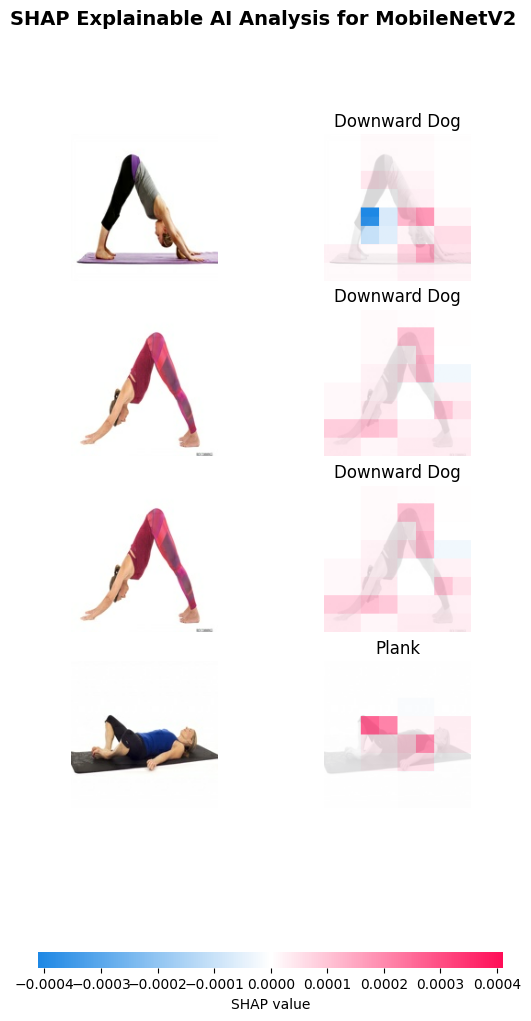

SHAP PDF saved: /kaggle/working/Yoga-Pose-Recognition/XAI_Figures/shap_mobilenetv2_explainable_ai.pdf


,image_index,true_class,predicted_class,confidence
0,19,Downward Dog,Downward Dog,0.998395
1,61,Downward Dog,Downward Dog,0.997456
2,71,Downward Dog,Downward Dog,0.997456
3,162,Goddess,Plank,0.922478


In [21]:

# ============================================================
# Cell 18C: SHAP Image Explanations for MobileNetV2 - Saved as PDF
# ============================================================

# SHAP can be computationally heavy. This cell uses a small number of representative images.
# If SHAP is not installed in the Kaggle environment, run: pip install shap

try:
    import shap
    shap_available = True
except Exception as e:
    shap_available = False
    print("SHAP is not available in this environment.")
    print("Install it first in a new Kaggle cell using: !pip install shap")
    print("Original error:", e)

if shap_available:
    # Use a small image subset so the cell can run on Kaggle without excessive time.
    shap_indices = selected_xai_indices[:4]
    shap_images = all_images[shap_indices].astype("float32")

    # Prediction function for SHAP. It receives images and returns model probabilities.
    def shap_predict_function(x):
        x = np.array(x).astype("float32")
        return mobilenet_model(x, training=False).numpy()

    masker = shap.maskers.Image("blur(20,20)", shap_images[0].shape)
    explainer = shap.Explainer(
        shap_predict_function,
        masker,
        output_names=[display_names[c] for c in class_names]
    )

    # Lower max_evals makes the run faster. Increase it later if you want smoother explanations.
    shap_values = explainer(
        shap_images,
        max_evals=200,
        batch_size=16,
        outputs=shap.Explanation.argsort.flip[:1]
    )

    shap_pdf_path = os.path.join(XAI_DIR, "shap_mobilenetv2_explainable_ai.pdf")

    plt.figure()
    shap.image_plot(shap_values, shap_images.astype("uint8"), show=False)
    plt.suptitle("SHAP Explainable AI Analysis for MobileNetV2", fontsize=14, fontweight="bold")
    plt.savefig(shap_pdf_path, dpi=300, bbox_inches="tight")
    plt.show()

    shap_summary_df = pd.DataFrame({
        "image_index": shap_indices,
        "true_class": [display_names[class_names[int(all_labels[i])]] for i in shap_indices],
        "predicted_class": [display_names[class_names[int(pred_labels_all[i])]] for i in shap_indices],
        "confidence": [float(confidence_all[i]) for i in shap_indices]
    })

    shap_summary_df.to_excel(
        os.path.join(XAI_RESULT_DIR, "shap_selected_images.xlsx"),
        index=False
    )

    print("SHAP PDF saved:", shap_pdf_path)
    display(shap_summary_df)


In [22]:

# ============================================================
# Cell 18D: Save Short Text for the Article XAI Section
# ============================================================

xai_article_text = """
Explainable AI was added to inspect whether the MobileNetV2 model used meaningful visual regions when predicting yoga poses.
Grad-CAM was applied to selected correct and misclassified test images to highlight the spatial regions that contributed most strongly to the predicted class.
The Grad-CAM results should be interpreted as visual evidence of model attention rather than proof of correct reasoning.
SHAP image explanations were also generated for representative test images using blurred image masking.
The SHAP outputs show image regions that positively or negatively support the predicted class probability.
Together, Grad-CAM and SHAP help evaluate whether the model focuses on the human body and pose structure or whether it relies on irrelevant background information.
"""

with open(os.path.join(XAI_RESULT_DIR, "xai_article_text.txt"), "w", encoding="utf-8") as f:
    f.write(xai_article_text)

print("XAI article text saved:", os.path.join(XAI_RESULT_DIR, "xai_article_text.txt"))
print(xai_article_text)


XAI article text saved: /kaggle/working/Yoga-Pose-Recognition/XAI_Results/xai_article_text.txt

Explainable AI was added to inspect whether the MobileNetV2 model used meaningful visual regions when predicting yoga poses.
Grad-CAM was applied to selected correct and misclassified test images to highlight the spatial regions that contributed most strongly to the predicted class.
The Grad-CAM results should be interpreted as visual evidence of model attention rather than proof of correct reasoning.
SHAP image explanations were also generated for representative test images using blurred image masking.
The SHAP outputs show image regions that positively or negatively support the predicted class probability.
Together, Grad-CAM and SHAP help evaluate whether the model focuses on the human body and pose structure or whether it relies on irrelevant background information.



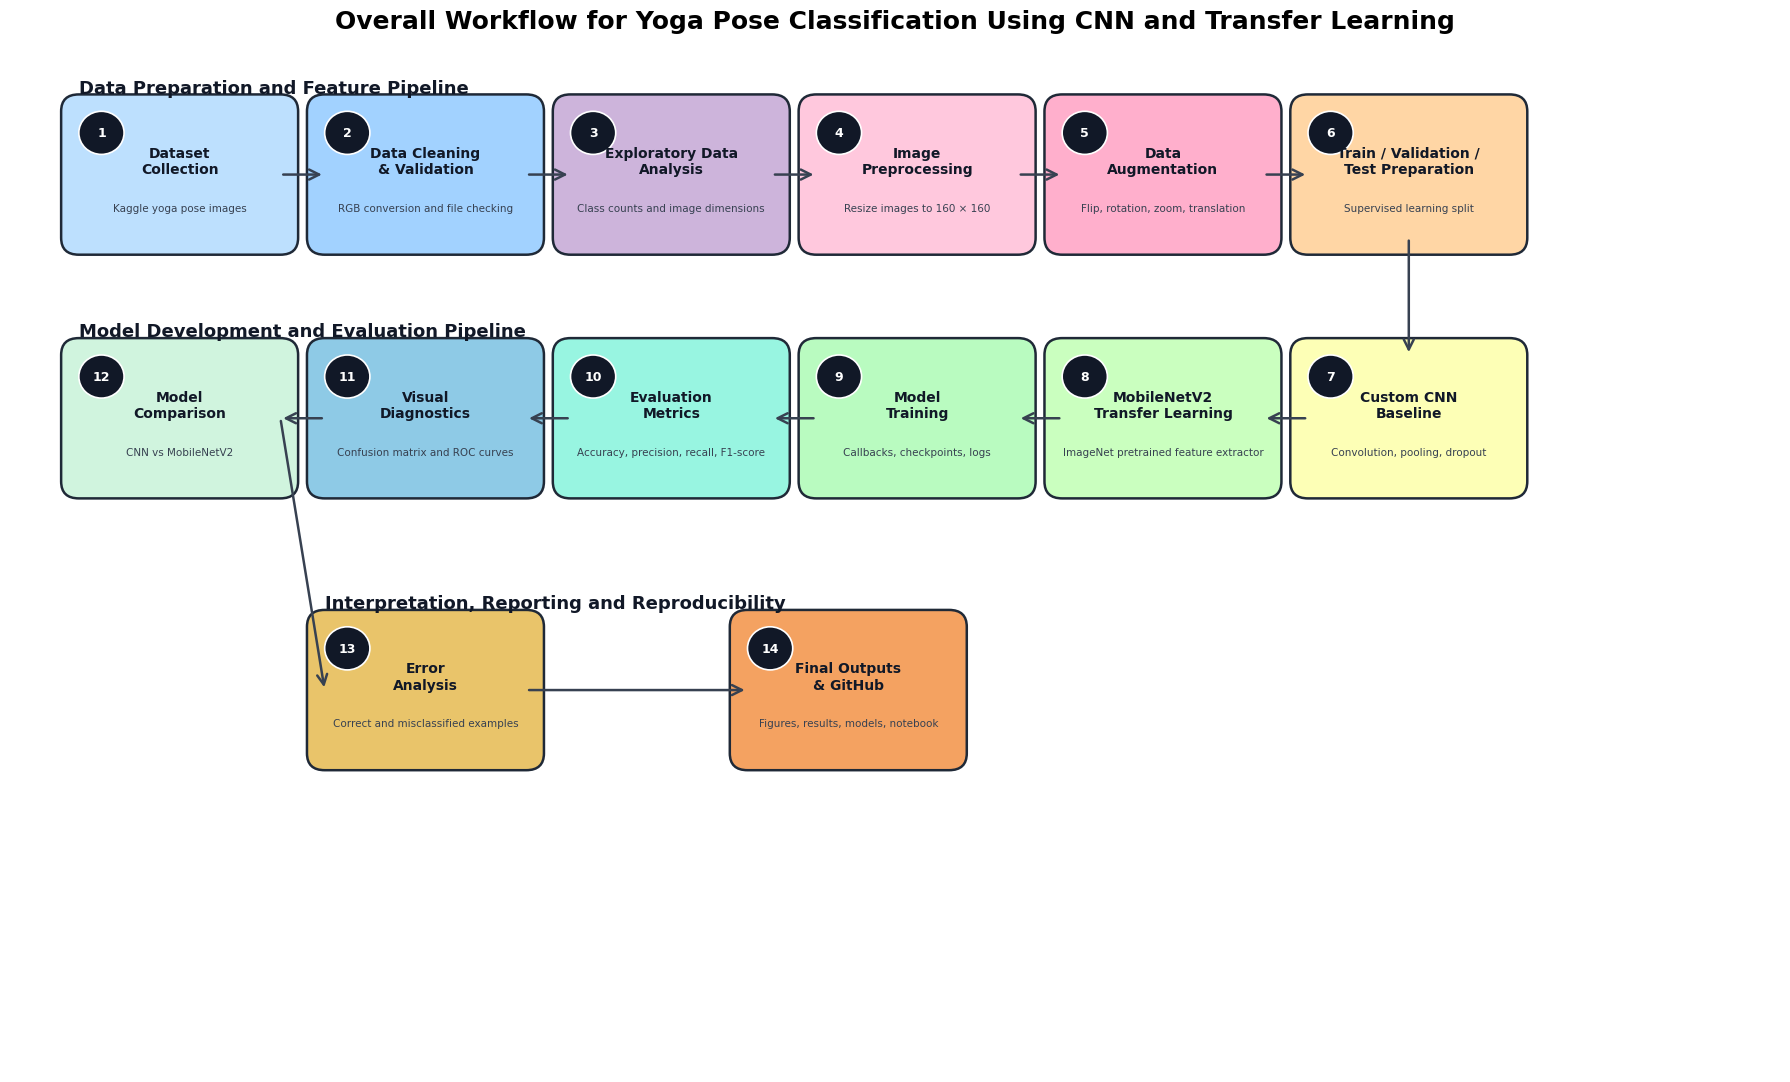

Polished numbered workflow diagram saved.


In [23]:
# ============================================================
# Polished Numbered Workflow Diagram
# ============================================================

import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

FIGURE_DIR = "/kaggle/working/Yoga-Pose-Recognition/Figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(18, 11))
ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis("off")

steps = [
    ("1", "Dataset\nCollection", "Kaggle yoga pose images"),
    ("2", "Data Cleaning\n& Validation", "RGB conversion and file checking"),
    ("3", "Exploratory Data\nAnalysis", "Class counts and image dimensions"),
    ("4", "Image\nPreprocessing", "Resize images to 160 × 160"),
    ("5", "Data\nAugmentation", "Flip, rotation, zoom, translation"),
    ("6", "Train / Validation /\nTest Preparation", "Supervised learning split"),
    ("7", "Custom CNN\nBaseline", "Convolution, pooling, dropout"),
    ("8", "MobileNetV2\nTransfer Learning", "ImageNet pretrained feature extractor"),
    ("9", "Model\nTraining", "Callbacks, checkpoints, logs"),
    ("10", "Evaluation\nMetrics", "Accuracy, precision, recall, F1-score"),
    ("11", "Visual\nDiagnostics", "Confusion matrix and ROC curves"),
    ("12", "Model\nComparison", "CNN vs MobileNetV2"),
    ("13", "Error\nAnalysis", "Correct and misclassified examples"),
    ("14", "Final Outputs\n& GitHub", "Figures, results, models, notebook"),
]

positions = [
    (0.7, 8.9), (3.2, 8.9), (5.7, 8.9), (8.2, 8.9), (10.7, 8.9), (13.2, 8.9),
    (13.2, 6.3), (10.7, 6.3), (8.2, 6.3), (5.7, 6.3), (3.2, 6.3), (0.7, 6.3),
    (3.2, 3.4), (7.5, 3.4)
]

colors = [
    "#BDE0FE", "#A2D2FF", "#CDB4DB", "#FFC8DD", "#FFAFCC", "#FFD6A5",
    "#FDFFB6", "#CAFFBF", "#B9FBC0", "#98F5E1", "#8ECAE6", "#D0F4DE",
    "#E9C46A", "#F4A261"
]

box_w = 2.05
box_h = 1.35

def add_step(num, title, subtitle, x, y, color):
    box = FancyBboxPatch(
        (x, y),
        box_w,
        box_h,
        boxstyle="round,pad=0.18,rounding_size=0.18",
        linewidth=1.8,
        edgecolor="#1f2937",
        facecolor=color
    )
    ax.add_patch(box)

    circle = Circle(
        (x + 0.23, y + box_h - 0.23),
        0.23,
        facecolor="#111827",
        edgecolor="white",
        linewidth=1.2
    )
    ax.add_patch(circle)

    ax.text(
        x + 0.23,
        y + box_h - 0.23,
        num,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

    ax.text(
        x + box_w / 2,
        y + 0.82,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#111827"
    )

    ax.text(
        x + box_w / 2,
        y + 0.32,
        subtitle,
        ha="center",
        va="center",
        fontsize=7.5,
        color="#374151"
    )

def add_arrow_between(p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    start = (x1 + box_w, y1 + box_h / 2)
    end = (x2, y2 + box_h / 2)

    if x2 < x1:
        start = (x1, y1 + box_h / 2)
        end = (x2 + box_w, y2 + box_h / 2)

    if abs(x2 - x1) < 0.5:
        start = (x1 + box_w / 2, y1)
        end = (x2 + box_w / 2, y2 + box_h)

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.8,
        color="#374151",
        connectionstyle="arc3,rad=0.0"
    )
    ax.add_patch(arrow)

for (step, pos, color) in zip(steps, positions, colors):
    add_step(step[0], step[1], step[2], pos[0], pos[1], color)

for i in range(len(positions) - 1):
    add_arrow_between(positions[i], positions[i + 1])

# Section labels
ax.text(
    0.7,
    10.45,
    "Data Preparation and Feature Pipeline",
    fontsize=13,
    fontweight="bold",
    color="#111827"
)

ax.text(
    0.7,
    7.85,
    "Model Development and Evaluation Pipeline",
    fontsize=13,
    fontweight="bold",
    color="#111827"
)

ax.text(
    3.2,
    4.95,
    "Interpretation, Reporting and Reproducibility",
    fontsize=13,
    fontweight="bold",
    color="#111827"
)

plt.suptitle(
    "Overall Workflow for Yoga Pose Classification Using CNN and Transfer Learning",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "polished_numbered_workflow_diagram.pdf"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Polished numbered workflow diagram saved.")